# Lab 3: Estimation of π using Monte Carlo Simulation

## Theory

Monte Carlo Simulation is a computational technique that uses repeated random sampling to obtain numerical solutions for mathematical and physical problems. The method is particularly useful for problems involving probability, uncertainty, and complex systems where analytical solutions are difficult or impossible to obtain. It relies on generating a large number of random samples and using statistical principles to approximate the desired result.

One of the classic applications of the Monte Carlo method is the estimation of the mathematical constant π (pi). The idea is based on the geometric relationship between a square and an inscribed circle. Consider a square of side length 1 containing a circle of radius 0.5. The area of the square is:

A_square = 1² = 1

The area of the inscribed circle is:

A_circle = πr² = π(0.5)² = π/4

Therefore, the probability that a randomly generated point inside the square also lies inside the circle is:

P = A_circle / A_square = π/4

Rearranging the equation gives:

π = 4P

To estimate π, a large number of random points are generated uniformly inside the square. For each generated point (x, y), its distance from the center of the square is calculated. If the point satisfies:

x² + y² ≤ r²

then it lies inside the circle; otherwise, it lies outside.

If:

* N = Total number of generated points
* M = Number of points inside the circle

then the Monte Carlo estimate of π is:

π ≈ 4(M/N)

As the number of randomly generated points increases, the estimated value converges toward the actual value of π according to the Law of Large Numbers. The accuracy of the estimation improves with larger sample sizes, although the computational cost also increases.

Monte Carlo simulation is widely used in engineering, finance, physics, operations research, machine learning, artificial intelligence, risk analysis, and scientific computing because of its ability to solve high-dimensional and probabilistic problems efficiently.

In this experiment, uniformly distributed random points are generated inside a square using Python's pseudo-random number generator. The number of points falling inside the inscribed circle is counted, and the ratio of points is used to estimate the value of π. The generated points are also visualized graphically to illustrate the Monte Carlo sampling process.

## Program Codes:

----------------------
1000 drops
π estimated as: 3.032000
----------------------


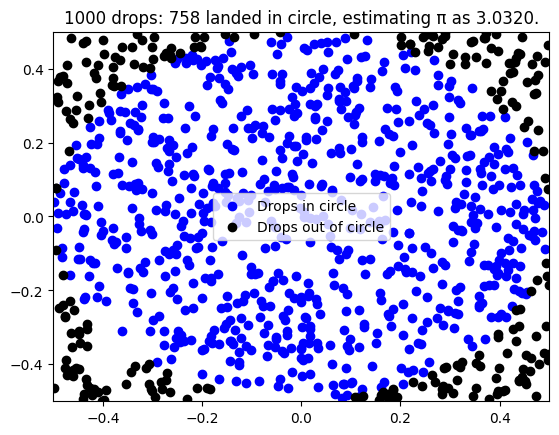

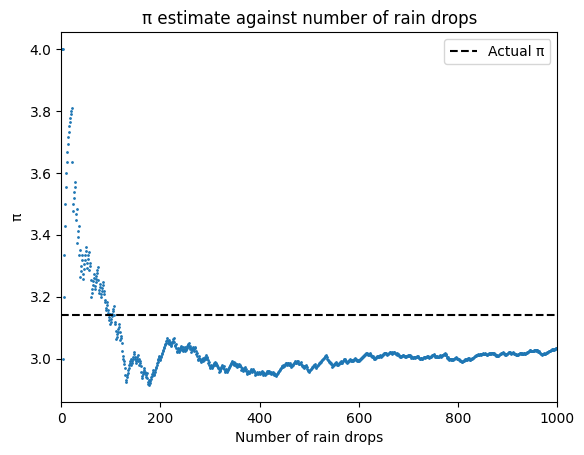

In [17]:
from __future__ import division
from random import random
from math import pi
import matplotlib.pyplot as plt
import sys


def rain_drop(length_of_field=1):
    return [(.5 - random()) * length_of_field, (.5 - random()) * length_of_field]


def is_point_in_circle(point, length_of_field=1):
    return (point[0]) ** 2 + (point[1]) ** 2 <= (length_of_field / 2) ** 2


def plot_rain_drops(drops_in_circle, drops_out_of_circle, length_of_field=1, format='png'):
    plt.figure()
    plt.xlim(-length_of_field / 2, length_of_field / 2)
    plt.ylim(-length_of_field / 2, length_of_field / 2)
    plt.scatter([e[0] for e in drops_in_circle], [e[1] for e in drops_in_circle], color='blue', label="Drops in circle")
    plt.scatter([e[0] for e in drops_out_of_circle], [e[1] for e in drops_out_of_circle], color='black', label="Drops out of circle")
    plt.legend(loc="center")
    plt.title(f"{len(drops_in_circle) + len(drops_out_of_circle)} drops: {len(drops_in_circle)} landed in circle, estimating π as {4 * len(drops_in_circle) / (len(drops_in_circle) + len(drops_out_of_circle)):.4f}.")
    plt.savefig(f"rain_drops.{format}")
    

def plot_pi_estimates(pi_estimate, total_drops):
    plt.figure()
    plt.scatter(range(1, total_drops + 1), pi_estimate, s=1)
    plt.hlines(pi, 0, total_drops, color='black', linestyle='dashed', label="Actual π")
    plt.xlim(0, total_drops)
    plt.title("π estimate against number of rain drops")
    plt.xlabel("Number of rain drops")
    plt.ylabel("π")
    plt.legend()
    plt.savefig(f"pi_estimate_{total_drops}_drops.png")
    

def rain(number_of_drops=1000, length_of_field=1, plot=True, dynamic=False):
    number_of_drops_in_circle = 0
    drops_in_circle = []
    drops_out_of_circle = []
    pi_estimate = []
    for k in range(number_of_drops):
        drop = rain_drop(length_of_field)
        if is_point_in_circle(drop, length_of_field):
            drops_in_circle.append(drop)
            number_of_drops_in_circle += 1
        else:
            drops_out_of_circle.append(drop)
        pi_estimate.append(4 * number_of_drops_in_circle / (k + 1))
    
    if plot and not dynamic:
        plot_rain_drops(drops_in_circle, drops_out_of_circle, length_of_field)
        plot_pi_estimates(pi_estimate, number_of_drops)
    return number_of_drops_in_circle, number_of_drops
 
 
if __name__ == "__main__":
    try:
        if 'ipykernel' in sys.modules:
            number_of_drops = int(input("Enter the number of drops: "))
        else:
            if len(sys.argv) > 1:
                number_of_drops = int(sys.argv[1])
            else:
                number_of_drops = int(input("Enter the number of drops: "))
                
        result = rain(number_of_drops, plot=True, dynamic=False)
        print("----------------------")
        print(f"{number_of_drops} drops")
        print(f"π estimated as: {4 * result[0] / result[1]:.6f}")
        print("----------------------")
    except ValueError:
        print("Invalid input! Please provide an integer for the number of drops.")

### Estimation of π using Monte Carlo Simulation

This program implements the Monte Carlo simulation technique to estimate the value of π. Random points are generated uniformly inside a square, and each point is tested to determine whether it falls inside the inscribed circle. The ratio of the number of points inside the circle to the total number of generated points is multiplied by four to obtain an approximation of π.

The program also visualizes the generated random points, distinguishing those that lie inside and outside the circle, and plots the convergence of the estimated π value as the number of generated samples increases. Increasing the number of random points generally produces a more accurate estimate of π.

## Discussion

The Monte Carlo simulation successfully estimated the value of π by generating uniformly distributed random points within a square and determining how many of them fell inside the inscribed circle. The graphical representation clearly illustrated the random sampling process, while the convergence plot demonstrated that the estimated value gradually approached the actual value of π as the number of generated samples increased.

The experiment highlights the probabilistic nature of Monte Carlo methods. Since the estimation depends on randomly generated samples, different executions may produce slightly different values of π. However, increasing the number of samples reduces statistical fluctuations and improves the accuracy of the estimation due to the Law of Large Numbers.

The visualization of points inside and outside the circle provides an intuitive understanding of geometric probability. The convergence graph further confirms that larger sample sizes lead to increasingly stable estimates. Although Monte Carlo methods may require many samples to achieve high precision, they remain valuable for solving problems where deterministic analytical solutions are difficult or computationally expensive.

Overall, the experiment demonstrates the effectiveness of Monte Carlo simulation as a numerical approximation technique and illustrates one of its simplest and most widely known applications.

## Conclusion

The experiment successfully demonstrated the estimation of the mathematical constant π using the Monte Carlo simulation technique. Random points were generated uniformly inside a square, and the proportion of points lying within the inscribed circle was used to approximate the value of π.

The estimated value became increasingly accurate as the number of generated samples increased, illustrating the convergence properties of Monte Carlo methods. The experiment also demonstrated the practical application of random number generation, probability, and statistical sampling in numerical computation.

Monte Carlo simulation provides a simple yet powerful approach for solving complex mathematical and engineering problems involving uncertainty. The experiment reinforced the importance of random sampling techniques and their applications in scientific computing, simulation, optimization, and statistical analysis.